# Clase 8 · Repaso de ML para construir soluciones

### De los datos al modelo, y del modelo a una aplicación de salud

El objetivo no es salir sabiendo programar algoritmos de ML. Es poder reconocer **qué pregunta queremos responder**, qué tipo de datos necesita y qué opciones conviene comparar al construir una solución.

Como programadores y administradores de bases, ustedes van a definir cómo se preparan y conectan los datos, cómo se integra una predicción y cómo se controla el resultado. El modelo es una parte del sistema.

### Al terminar vas a poder

- explicar con palabras simples qué aprende un modelo y qué devuelve;
- diferenciar tareas según la respuesta esperada: categoría, número o patrón;
- reconocer por qué hay varias familias de algoritmos y qué tipo de patrón capturan;
- traducir una necesidad de salud a una forma de problema de ML;
- identificar qué decisiones de datos, evaluación e integración corresponden al equipo que construye la solución.

**No hace falta aprender el código de las muestras.** Las celdas están plegadas y sus gráficos listos para mirar y discutir.

## 01 · Qué significa que un sistema aprenda

En software tradicional, una persona escribe reglas explícitas: `si pasa A, entonces hacer B`. En ML, le mostramos muchos ejemplos anteriores y sus resultados. El algoritmo busca regularidades en esos ejemplos; el modelo guarda lo aprendido y lo usa para estimar un resultado nuevo.

**Ejemplo conocido para un equipo de software:** clasificar tickets de soporte como «rutina» o «requiere guardia». Las columnas podrían incluir horario, componente afectado y cantidad de errores; el resultado histórico del ticket sirve como respuesta para aprender.

El modelo no conoce la causa del problema ni entiende el contexto como una persona. Reconoce patrones en los datos que recibió y puede equivocarse cuando cambian los datos o el escenario.

### Traducido a vocabulario de base de datos

| Término de ML | Cómo pensarlo al mirar una tabla | Ejemplo de ticket |
|---|---|---|
| **Caso / observación** | Una fila | Un ticket cerrado |
| **Entrada** | Columnas que estaban disponibles para estimar | Servicio, hora, errores |
| **Objetivo / etiqueta** | La respuesta que el sistema intenta estimar | Rutina o guardia |
| **Algoritmo** | La receta que busca patrones en ejemplos | Árbol de decisiones |
| **Modelo** | La receta después de aprender de los datos | Árbol ya entrenado |
| **Predicción** | La estimación para un caso nuevo | Posible guardia |

En la práctica, esta distinción guía el trabajo sobre tablas, vistas, procesos ETL y APIs. Una columna que se completa después de cerrar el ticket no puede usarse para decidir su prioridad al comienzo.

### El modelo dentro del producto

Primero se preparan ejemplos y se compara si el modelo generaliza a casos que no usó para aprender. Después se empaqueta una versión del modelo y la aplicación la consulta en el momento necesario.

La fuente Mermaid del diagrama está disponible para reutilizarla; la salida SVG aparece en la celda siguiente.

```mermaid
flowchart LR
    A[Datos fuente] --> B[Dataset con entradas y respuesta]
    B --> C[Entrenar y probar]
    C --> D[Modelo versionado]
    D --> E[API, lote o interfaz]
    E --> F[Revisión y monitoreo]
    F -. mejorar la próxima versión .-> B
```

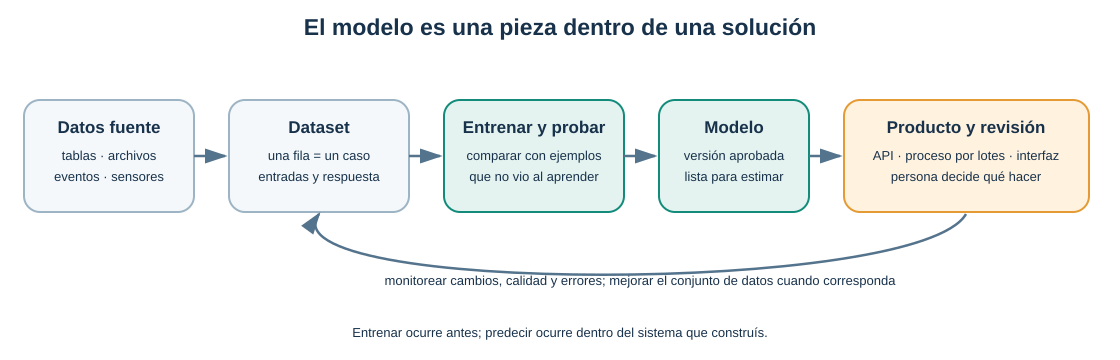

In [2]:
from IPython.display import SVG, display

display(SVG(r"""<svg xmlns="http://www.w3.org/2000/svg" width="1120" height="360" viewBox="0 0 1120 360" role="img" aria-label="Flujo de un producto que usa aprendizaje automático desde los datos hasta el monitoreo">
<style>text{font-family:Arial,sans-serif;fill:#18324b}.title{font-size:23px;font-weight:700}.head{font-size:17px;font-weight:700}.sub{font-size:13px}.box{fill:#f4f8fb;stroke:#9db4c5;stroke-width:2}.accent{fill:#e4f3f0;stroke:#138b7a;stroke-width:2}.warn{fill:#fff2df;stroke:#e49b35;stroke-width:2}.line{stroke:#54738c;stroke-width:2.5;fill:none;marker-end:url(#arrow)}</style>
<defs><marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto"><path d="M0,0 L0,6 L9,3 z" fill="#54738c"/></marker></defs>
<text x="560" y="35" text-anchor="middle" class="title">El modelo es una pieza dentro de una solución</text>
<rect x="24" y="100" width="170" height="112" rx="16" class="box"/><text x="109" y="133" text-anchor="middle" class="head">Datos fuente</text><text x="109" y="160" text-anchor="middle" class="sub">tablas · archivos</text><text x="109" y="181" text-anchor="middle" class="sub">eventos · sensores</text>
<path d="M194 156 L225 156" class="line"/>
<rect x="229" y="100" width="180" height="112" rx="16" class="box"/><text x="319" y="133" text-anchor="middle" class="head">Dataset</text><text x="319" y="160" text-anchor="middle" class="sub">una fila = un caso</text><text x="319" y="181" text-anchor="middle" class="sub">entradas y respuesta</text>
<path d="M409 156 L440 156" class="line"/>
<rect x="444" y="100" width="180" height="112" rx="16" class="accent"/><text x="534" y="133" text-anchor="middle" class="head">Entrenar y probar</text><text x="534" y="160" text-anchor="middle" class="sub">comparar con ejemplos</text><text x="534" y="181" text-anchor="middle" class="sub">que no vio al aprender</text>
<path d="M624 156 L655 156" class="line"/>
<rect x="659" y="100" width="150" height="112" rx="16" class="accent"/><text x="734" y="133" text-anchor="middle" class="head">Modelo</text><text x="734" y="160" text-anchor="middle" class="sub">versión aprobada</text><text x="734" y="181" text-anchor="middle" class="sub">lista para estimar</text>
<path d="M809 156 L840 156" class="line"/>
<rect x="844" y="100" width="245" height="112" rx="16" class="warn"/><text x="966" y="133" text-anchor="middle" class="head">Producto y revisión</text><text x="966" y="160" text-anchor="middle" class="sub">API · proceso por lotes · interfaz</text><text x="966" y="181" text-anchor="middle" class="sub">persona decide qué hacer</text>
<path d="M966 214 C920 295 260 295 319 214" class="line"/><text x="640" y="285" text-anchor="middle" class="sub">monitorear cambios, calidad y errores; mejorar el conjunto de datos cuando corresponda</text>
<text x="560" y="337" text-anchor="middle" class="sub">Entrenar ocurre antes; predecir ocurre dentro del sistema que construís.</text>
</svg>"""))

En el dibujo, **entrenar** ocurre durante la preparación del modelo; **predecir** ocurre cuando el sistema recibe un caso nuevo. La predicción puede llegar a una API, un proceso programado o una interfaz para revisión.

Antes de elegir algoritmos se reserva una referencia simple —por ejemplo, responder siempre con la categoría más frecuente—. Si una solución compleja no mejora esa referencia en casos nuevos, todavía no justifica el costo de integrarla.

## 02 · Cómo aprende ML y por qué hay varios algoritmos

Los datos no siempre siguen el mismo tipo de patrón. A veces una relación se parece a una tendencia sencilla; a veces hace falta combinar condiciones; otras veces un caso se parece a ejemplos previos. Cada familia ofrece una manera distinta de aproximarse a esos patrones.

Por eso hay opciones: no porque haya un algoritmo ganador, sino porque cambian las formas de los datos, la cantidad de ejemplos, el tipo de respuesta y cuánto necesitamos entender o mantener el resultado.

### Dos tipos generales de aprendizaje

**Supervisado:** cada ejemplo tiene una respuesta conocida. Si la respuesta es una categoría usamos clasificación; si es un número, regresión.

**Sin etiqueta:** no hay una respuesta previa que copiar. Clustering propone grupos; la detección de anomalías resalta casos raros. Esos resultados describen los datos, pero no explican por sí solos por qué apareció un grupo o una rareza.

Una tercera idea útil para reconocer es el **aprendizaje por refuerzo**: un agente prueba acciones y recibe recompensas o penalizaciones. No es el centro de esta clase ni la primera opción para la mayoría de las tablas clínicas.

### Una guía corta para orientarse

| Familia / algoritmo | Intuición sencilla | Cuándo suele entrar en la comparación |
|---|---|---|
| **Regresión lineal** | Combina entradas para estimar una cantidad | Una primera opción numérica simple |
| **Regresión logística** | Estima una probabilidad para una categoría | Clases conocidas; referencia sencilla de clasificación |
| **Árbol de decisión** | Aprende preguntas del tipo «si…, entonces…» | Reglas y cortes fáciles de visualizar |
| **Bosque aleatorio** | Varios árboles votan o promedian | Tablas con combinaciones de patrones; reduce dependencia de un solo árbol |
| **Boosting de árboles** | Agrega árboles para corregir errores previos | Otro candidato potente para datos tabulares |
| **K vecinos (KNN)** | Compara el caso nuevo con casos parecidos | La cercanía entre ejemplos tiene sentido |
| **Máquina de vectores de soporte (SVM)** | Busca una frontera que separe clases | Otra forma de separar categorías, sensible a escala y parámetros |
| **K-means** | Forma grupos de casos parecidos sin respuesta conocida | Explorar segmentos cuando no hay etiquetas previas |
| **Isolation Forest** | Marca ejemplos que se apartan del conjunto | Explorar registros poco frecuentes; la marca requiere revisión |

**El mismo método puede tener variantes**, y estos no son los únicos algoritmos. La tabla alcanza para armar una primera comparación sin entrar en las matemáticas ni en la programación interna.

### Qué cambia entre estas opciones

- Una línea o una curva simple aprende relaciones compactas; puede quedarse corta si el patrón tiene muchos quiebres.
- Un árbol se parece a un conjunto de preguntas condicionales; si se hace muy grande, puede aprender detalles accidentales de los ejemplos.
- Un bosque reúne muchos árboles. El boosting también usa árboles, pero los agrega por etapas. Más complejidad no garantiza mejores resultados.
- KNN mira cercanía entre casos. Si las columnas tienen escalas muy distintas, una puede dominar la distancia.

Para comparar, mantenemos la pregunta y los datos iguales, probamos una referencia sencilla y revisamos los resultados en ejemplos que el modelo no vio durante el aprendizaje.

### El tipo de dato también cambia las herramientas

Los datos pueden llegar como una tabla, una secuencia ordenada, una imagen o un texto. La tarea todavía puede ser clasificar o estimar un valor, pero hay modelos especializados para representar esos formatos:

- en una **secuencia temporal**, el orden de las mediciones importa;
- en una **imagen**, puede interesar la categoría, la ubicación de un objeto o los píxeles de una región;
- en un **texto**, puede buscarse una categoría, una frase o un dato dentro del contexto.

En esta clase los vamos a reconocer con gráficos. No hace falta memorizar los nombres de las redes que los procesan.

### Un mapa para decidir la primera pregunta

El mapa no elige un ganador. Ayuda a ordenar la conversación: ¿tenemos respuestas anteriores?, ¿qué forma tiene la salida?, ¿queremos explorar datos sin etiqueta?

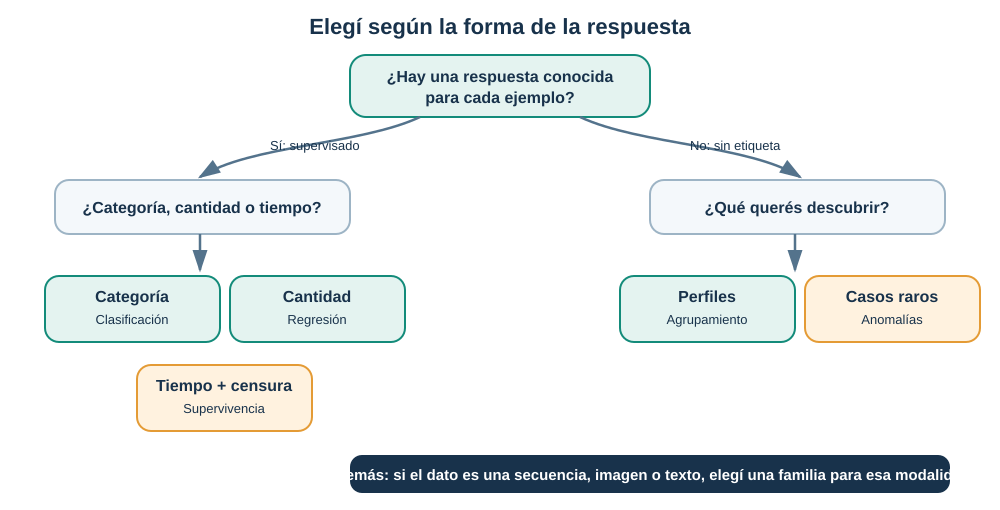

In [3]:
from IPython.display import SVG, display

display(SVG(r"""
<svg xmlns="http://www.w3.org/2000/svg" width="1000" height="510" viewBox="0 0 1000 510" role="img" aria-label="Mapa para elegir una familia de modelos según la salida y los datos disponibles">
<style>
  text{font-family:Arial,sans-serif;fill:#18324b}.title{font-size:22px;font-weight:700}.label{font-size:16px;font-weight:600}.small{font-size:13px}.box{fill:#f4f8fb;stroke:#9db4c5;stroke-width:2}.main{fill:#e4f3f0;stroke:#138b7a;stroke-width:2}.side{fill:#fff2df;stroke:#e49b35;stroke-width:2}.arrow{stroke:#54738c;stroke-width:2.5;fill:none;marker-end:url(#a)}
</style>
<defs><marker id="a" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto"><path d="M0,0 L0,6 L9,3 z" fill="#54738c"/></marker></defs>
<text x="500" y="34" text-anchor="middle" class="title">Elegí según la forma de la respuesta</text>
<rect x="350" y="55" width="300" height="62" rx="16" class="main"/><text x="500" y="82" text-anchor="middle" class="label">¿Hay una respuesta conocida</text><text x="500" y="103" text-anchor="middle" class="label">para cada ejemplo?</text>
<path d="M420 117 C360 145 250 145 200 177" class="arrow"/><path d="M580 117 C640 145 750 145 800 177" class="arrow"/>
<text x="270" y="150" class="small">Sí: supervisado</text><text x="690" y="150" class="small">No: sin etiqueta</text>
<rect x="55" y="180" width="295" height="54" rx="14" class="box"/><text x="202" y="213" text-anchor="middle" class="label">¿Categoría, cantidad o tiempo?</text>
<path d="M200 234 L200 270" class="arrow"/>
<rect x="45" y="276" width="175" height="66" rx="14" class="main"/><text x="132" y="302" text-anchor="middle" class="label">Categoría</text><text x="132" y="324" text-anchor="middle" class="small">Clasificación</text>
<rect x="230" y="276" width="175" height="66" rx="14" class="main"/><text x="317" y="302" text-anchor="middle" class="label">Cantidad</text><text x="317" y="324" text-anchor="middle" class="small">Regresión</text>
<rect x="137" y="365" width="175" height="66" rx="14" class="side"/><text x="224" y="391" text-anchor="middle" class="label">Tiempo + censura</text><text x="224" y="413" text-anchor="middle" class="small">Supervivencia</text>
<rect x="650" y="180" width="295" height="54" rx="14" class="box"/><text x="797" y="213" text-anchor="middle" class="label">¿Qué querés descubrir?</text>
<path d="M795 234 L795 270" class="arrow"/>
<rect x="620" y="276" width="175" height="66" rx="14" class="main"/><text x="707" y="302" text-anchor="middle" class="label">Perfiles</text><text x="707" y="324" text-anchor="middle" class="small">Agrupamiento</text>
<rect x="805" y="276" width="175" height="66" rx="14" class="side"/><text x="892" y="302" text-anchor="middle" class="label">Casos raros</text><text x="892" y="324" text-anchor="middle" class="small">Anomalías</text>
<rect x="350" y="455" width="600" height="38" rx="12" fill="#18324b"/><text x="650" y="480" text-anchor="middle" style="font:600 15px Arial;fill:white">Además: si el dato es una secuencia, imagen o texto, elegí una familia para esa modalidad.</text>
</svg>
"""))

El mapa es un punto de partida, no una receta automática. Antes de decidir, confirmá que los ejemplos representan los casos donde se usaría la predicción y que la respuesta histórica está bien definida.

| Necesidad conocida fuera de salud | Forma de salida | Familia candidata |
|---|---|---|
| Clasificar tickets de soporte | Categoría | Clasificación |
| Estimar cuánto tardará un proceso | Número | Regresión |
| Encontrar grupos de uso parecidos | Grupo, sin etiqueta anterior | Clustering |
| Detectar un pico inusual en logs | Marca de rareza | Anomalías |
| Anticipar carga de un servidor | Valores ordenados en el futuro | Serie temporal |
| Clasificar o resaltar un objeto en una foto | Clase, caja o máscara | Visión por computadora |
| Separar una consulta por tema | Categoría o información extraída | NLP |

## 03 · El puente a soluciones de salud

Ahora aplicamos la misma lógica a un dominio donde importa especialmente cómo se definen los casos y los errores. La lista de algoritmos no cambia de golpe: primero identificamos la pregunta y el tipo de respuesta, luego vemos qué candidato comparar.

La muestra usa una tabla pequeña **sintética**, creada para enseñar conceptos. No representa pacientes reales ni permite sacar conclusiones médicas.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
PALETTE = {"azul": "#315a9b", "verde": "#138b7a", "naranja": "#e49b35", "rojo": "#c95d63", "gris": "#647586", "claro": "#e8eef3"}
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#cad4dd",
    "axes.labelcolor": "#18324b", "text.color": "#18324b", "xtick.color": "#52687a",
    "ytick.color": "#52687a", "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.labelsize": 10, "font.size": 10, "grid.color": "#dfe6ec", "grid.alpha": 0.8,
})
ruta_datos = Path("dataset_pacientes.csv")
if not ruta_datos.exists():
    ruta_datos = Path("../dataset_pacientes.csv")
df = pd.read_csv(ruta_datos)
print(f"Datos cargados: {len(df)} filas sintéticas · {df.shape[1]} columnas")
display(df.head(4))

Datos cargados: 600 filas sintéticas · 13 columnas


,id,edad,sexo,imc,tension_sistolica,tension_diastolica,glucemia,colesterol,fumador,actividad_fisica,horas_sueno,riesgo,dias_internacion
0,1,24,F,22.3,91,79,89,163,0,1,6.1,1,1
1,2,73,M,26.5,103,79,84,177,0,1,5.0,0,1
2,3,65,F,27.8,127,77,110,232,0,0,5.7,1,2
3,4,49,F,20.9,135,64,113,174,0,0,7.0,0,3


### Qué contiene — y qué no — esta muestra

Hay 600 filas sintéticas con edad, IMC, presión, glucemia, colesterol y hábitos. `riesgo` es una etiqueta binaria inventada para el ejercicio; `dias_internacion` va de 0 a 5 en estos datos. La columna `id` identifica la fila y no debe usarse como señal clínica.

No tenemos imágenes, notas clínicas, varias mediciones por persona ni seguimientos con eventos incompletos. Por eso las siguientes secciones tienen dos clases de ejemplos: algunos salen de la tabla y otros son gráficos esquemáticos creados para ilustrar una forma de dato.

### Preguntas de salud traducidas a tareas de ML

| Pregunta de producto o investigación | Forma de respuesta | Primeras opciones a comparar |
|---|---|---|
| ¿A qué casos conviene dar prioridad para una revisión? | Categoría o probabilidad | Regresión logística, árbol, bosque, boosting |
| ¿Cuánto podría durar una internación ya finalizada? | Cantidad de días | Regresión lineal, árbol o bosque de regresión |
| ¿Cuánto falta para una reconsulta si parte del seguimiento sigue abierto? | Tiempo hasta evento | Análisis de supervivencia |
| ¿Qué perfiles de controles aparecen sin etiquetas previas? | Agrupamientos exploratorios | K-means u otro clustering |
| ¿Qué lecturas merecen control de calidad? | Marca de rareza | Reglas de validación y detección de anomalías |
| ¿Qué podría pasar en las próximas mediciones? | Secuencia futura | Modelo temporal comparado con una referencia sencilla |
| ¿Qué región de una imagen debe revisar un especialista? | Caja, máscara o categoría | Visión por computadora |
| ¿Qué síntomas menciona una nota y están negados o afirmados? | Entidades con contexto | NLP |

La elección depende de cómo se registró cada resultado y de cuándo se necesita la estimación. El nombre del algoritmo es una parte pequeña de esa definición.

### El trabajo del equipo que construye la solución

En un proyecto real, desarrollo y datos suelen tener que resolver preguntas como estas antes de afinar un modelo:

1. **Fila:** ¿representa a una persona, una internación, una medición o un evento?
2. **Momento:** ¿qué datos estaban disponibles cuando se debía predecir?
3. **Etiqueta:** ¿quién registró el resultado y qué casos quedan sin respuesta?
4. **Uniones:** ¿los `JOIN` duplican casos o mezclan tiempos y personas?
5. **Evaluación:** ¿separamos personas o periodos para evitar que casos casi iguales queden a ambos lados?
6. **Producto:** ¿la salida va a una tabla diaria, un endpoint o una pantalla de revisión?
7. **Operación:** ¿guardamos versión, errores y cambios de datos para detectar cuándo deja de funcionar bien?

Este trabajo suele ser más decisivo para que el sistema sea confiable que conocer los detalles matemáticos de cada algoritmo.

## 04 · Muestra guiada: clasificación en una tabla de salud

Acá sí usamos los dos primeros conceptos juntos: hay una etiqueta histórica (`riesgo`) y la salida es una categoría. Los seis paneles aplican distintos clasificadores a las mismas dos columnas del conjunto sintético: glucemia y presión sistólica.

Antes de mirar el dibujo: cada **punto** es una fila; su color muestra la etiqueta de esa fila; el **fondo** muestra qué clase asignaría el modelo en esa zona. La frontera entre fondos es una representación de su decisión.

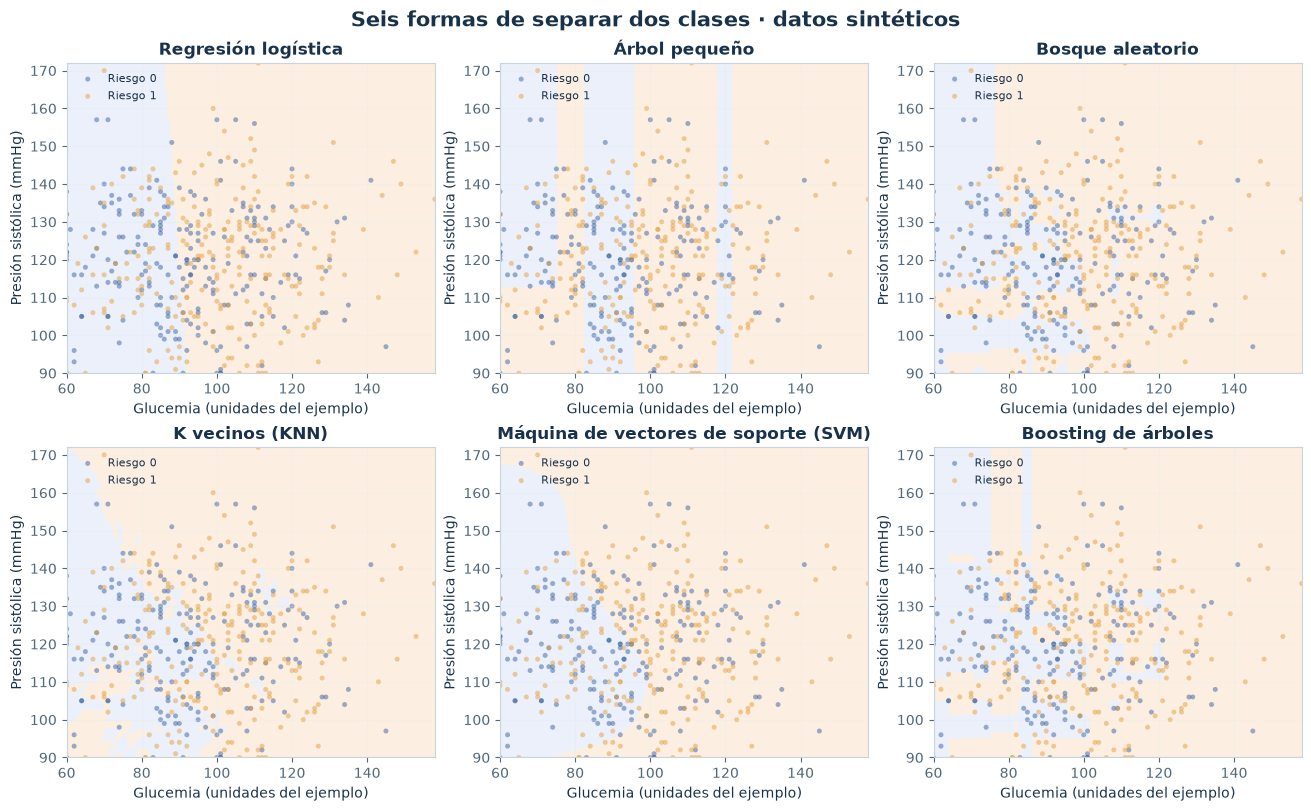

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from matplotlib.colors import ListedColormap
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

pares = ["glucemia", "tension_sistolica"]
X = df[pares]
y = df["riesgo"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
modelos_clasificacion = {
    "Regresión logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)),
    "Árbol pequeño": DecisionTreeClassifier(max_depth=3, min_samples_leaf=18, random_state=SEED),
    "Bosque aleatorio": RandomForestClassifier(n_estimators=140, min_samples_leaf=10, random_state=SEED),
    "K vecinos (KNN)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=25)),
    "Máquina de vectores de soporte (SVM)": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0)),
    "Boosting de árboles": HistGradientBoostingClassifier(max_iter=60, max_leaf_nodes=7, l2_regularization=1.0, random_state=SEED),
}
for modelo in modelos_clasificacion.values():
    modelo.fit(X_train, y_train)

xx, yy = np.meshgrid(
    np.linspace(X[pares[0]].min(), X[pares[0]].max(), 170),
    np.linspace(X[pares[1]].min(), X[pares[1]].max(), 170),
)
malla = np.c_[xx.ravel(), yy.ravel()]
fondo = ListedColormap(["#eaf0fa", "#fcefe1"])
fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
for ax, (nombre, modelo) in zip(axes.flat, modelos_clasificacion.items()):
    zonas = modelo.predict(malla).reshape(xx.shape)
    ax.contourf(xx, yy, zonas, levels=[-0.5, 0.5, 1.5], cmap=fondo, alpha=0.95)
    for clase, color, etiqueta in [(0, PALETTE["azul"], "Riesgo 0"), (1, PALETTE["naranja"], "Riesgo 1")]:
        subset = X_train[y_train == clase]
        ax.scatter(subset[pares[0]], subset[pares[1]], s=13, alpha=0.48, color=color, label=etiqueta, edgecolor="none")
    ax.set_title(nombre)
    ax.set_xlabel("Glucemia (unidades del ejemplo)")
    ax.set_ylabel("Presión sistólica (mmHg)")
    ax.grid(alpha=0.18)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Seis formas de separar dos clases · datos sintéticos", fontsize=15, fontweight="bold", color="#18324b")
plt.show()

### Qué comparar en los seis paneles

El gráfico ayuda a ver que cada familia traza fronteras de forma distinta. Una frontera más irregular significa mayor flexibilidad; **no significa automáticamente mayor calidad**.

En esta muestra las etiquetas fueron inventadas y las dos entradas del gráfico no contienen toda la información. El objetivo es reconocer formas de decisión, no decidir qué patrón clínico predomina.

### Cómo revisar si las predicciones ayudan

Para un clasificador no alcanza con contar aciertos totales. También miramos los tipos de error:

- **Falso positivo:** el sistema marca para revisión un caso que no tenía la etiqueta.
- **Falso negativo:** el sistema deja pasar un caso que sí tenía la etiqueta.

La matriz de confusión organiza esos aciertos y errores. La curva ROC muestra cómo cambia el balance entre casos detectados y falsas alarmas al variar el umbral. No hace falta memorizar el AUC: en la práctica importa saber qué resume y qué decisión se tomaría con el resultado.

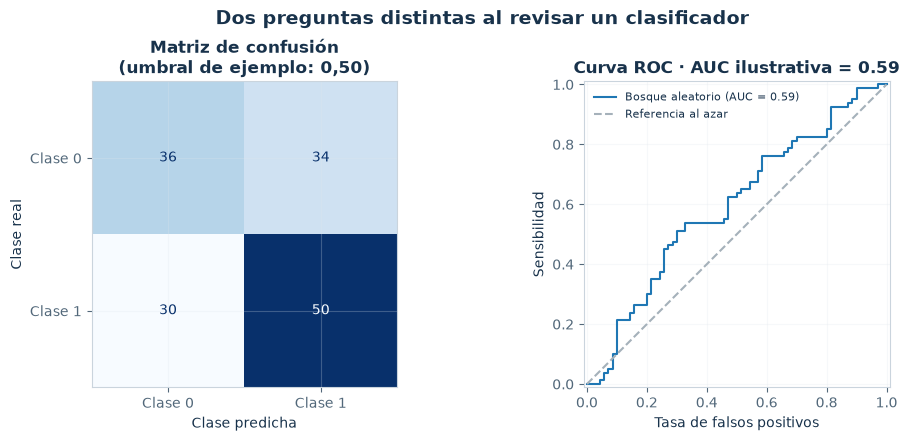

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

modelo_revision = modelos_clasificacion["Bosque aleatorio"]
prob_test = modelo_revision.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.50).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=["Clase 0", "Clase 1"],
    cmap="Blues", colorbar=False, ax=axes[0],
)
axes[0].set_title("Matriz de confusión\n(umbral de ejemplo: 0,50)")
RocCurveDisplay.from_predictions(y_test, prob_test, ax=axes[1], name="Bosque aleatorio")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#a5b1ba", label="Referencia al azar")
axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Sensibilidad")
axes[1].set_title(f"Curva ROC · AUC ilustrativa = {roc_auc_score(y_test, prob_test):.2f}")
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.grid(alpha=0.25)
fig.suptitle("Dos preguntas distintas al revisar un clasificador", fontsize=14, fontweight="bold")
plt.show()

La diagonal de la matriz son aciertos; los otros cuadros son errores. En un producto real, el umbral no se elige por costumbre: debe revisarse con quienes conocen el uso y las consecuencias de marcar u omitir casos.

Estos números vienen de una partición de un conjunto sintético. No son una medición de desempeño clínico.

## 05 · Muestra guiada: estimar una cantidad

Si el objetivo ahora es numérico, pasamos de clasificación a **regresión**. Vamos a comparar una recta con un bosque de regresión para estimar días de internación en la misma tabla inventada.

El gráfico compara cada estimación con su valor observado. La diagonal punteada representa coincidencia; el MAE resume el tamaño promedio del error en días.

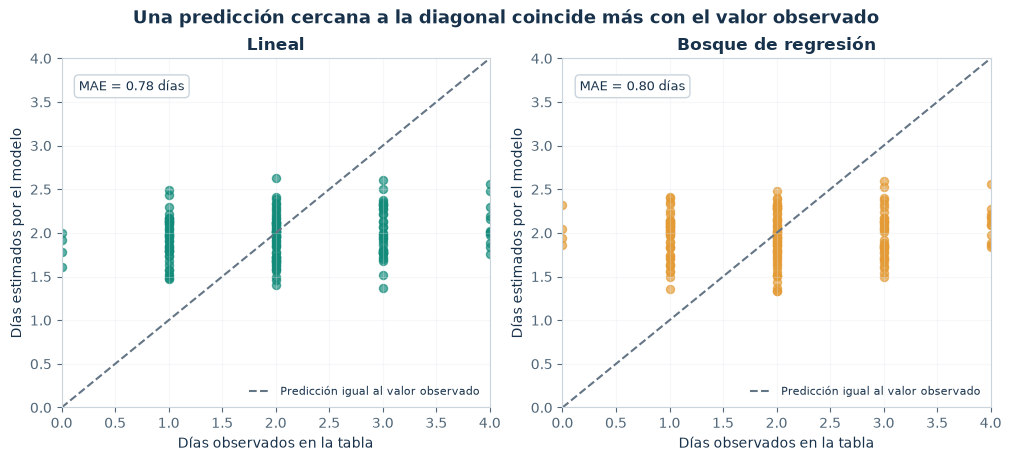

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

variables = ["edad", "imc", "tension_sistolica", "glucemia", "colesterol", "fumador", "actividad_fisica", "horas_sueno"]
Xr = df[variables]
yr = df["dias_internacion"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=SEED)
regresores = {
    "Lineal": make_pipeline(StandardScaler(), LinearRegression()),
    "Bosque de regresión": RandomForestRegressor(n_estimators=160, min_samples_leaf=8, random_state=SEED),
}
predicciones = {}
for nombre, modelo in regresores.items():
    modelo.fit(Xr_train, yr_train)
    predicciones[nombre] = modelo.predict(Xr_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
limites = [min(yr_test.min(), 0), max(yr_test.max(), max(p.max() for p in predicciones.values()))]
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    ax.scatter(yr_test, pred, color=PALETTE["verde"] if nombre == "Lineal" else PALETTE["naranja"], alpha=0.68, s=34)
    ax.plot(limites, limites, color=PALETTE["gris"], linestyle="--", label="Predicción igual al valor observado")
    ax.set_xlim(limites); ax.set_ylim(limites)
    ax.set_xlabel("Días observados en la tabla")
    ax.set_ylabel("Días estimados por el modelo")
    ax.set_title(nombre)
    ax.grid(alpha=0.3); ax.legend(frameon=False, fontsize=8)
    mae = mean_absolute_error(yr_test, pred)
    ax.text(0.04, 0.94, f"MAE = {mae:.2f} días", transform=ax.transAxes, va="top", fontsize=9,
            bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cad4dd"})
fig.suptitle("Una predicción cercana a la diagonal coincide más con el valor observado", fontsize=13, fontweight="bold")
plt.show()

### Lectura de la muestra

Un punto cerca de la diagonal tiene una estimación cercana al valor de referencia. El error promedio se expresa en días, una unidad fácil de explicar a quien integre la salida.

El ejercicio no indica que estos predictores alcancen para planificar altas. Si la internación todavía no terminó cuando se toma la muestra, el total de días aún no se conoce: esa pregunta puede necesitar un enfoque que considere que parte del seguimiento está abierto.

## 06 · Cuando no tenemos una respuesta previa

A veces el objetivo no es estimar una etiqueta sino **explorar** una tabla. En el gráfico de abajo, K-means agrupa filas parecidas según glucemia y presión; no utiliza `riesgo`.

Elegimos tres grupos para la demostración. Los grupos dependen de las columnas, la escala y esa cantidad que definimos al iniciar el análisis.

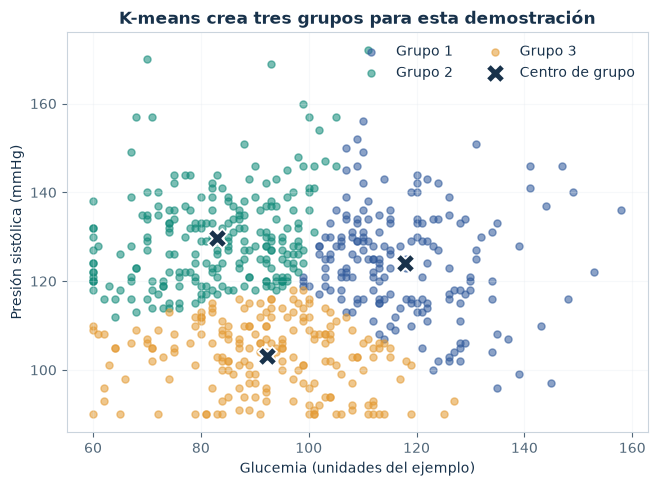

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

variables_cluster = ["glucemia", "tension_sistolica"]
Xc = df[variables_cluster]
escalador = StandardScaler()
Xc_esc = escalador.fit_transform(Xc)
agrupador = KMeans(n_clusters=3, n_init=20, random_state=SEED)
grupo = agrupador.fit_predict(Xc_esc)
centros = escalador.inverse_transform(agrupador.cluster_centers_)
colores = [PALETTE["azul"], PALETTE["verde"], PALETTE["naranja"]]
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for k, color in enumerate(colores):
    m = grupo == k
    ax.scatter(Xc.loc[m, variables_cluster[0]], Xc.loc[m, variables_cluster[1]], s=26, alpha=0.56, color=color, label=f"Grupo {k + 1}")
ax.scatter(centros[:, 0], centros[:, 1], marker="X", s=190, color="#18324b", edgecolor="white", linewidth=1.3, label="Centro de grupo")
ax.set_xlabel("Glucemia (unidades del ejemplo)")
ax.set_ylabel("Presión sistólica (mmHg)")
ax.set_title("K-means crea tres grupos para esta demostración")
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.25)
plt.show()

Los colores muestran la asignación del algoritmo y las cruces los centros de los grupos. Eso puede ayudar a hacer preguntas sobre los datos, pero no significa que hayan aparecido tres tipos de pacientes ni tres diagnósticos.

### Otro caso sin etiqueta: encontrar rarezas

Isolation Forest marca puntos que logra separar con pocas divisiones. El siguiente gráfico fuerza una pequeña proporción de marcas para mostrar la idea.

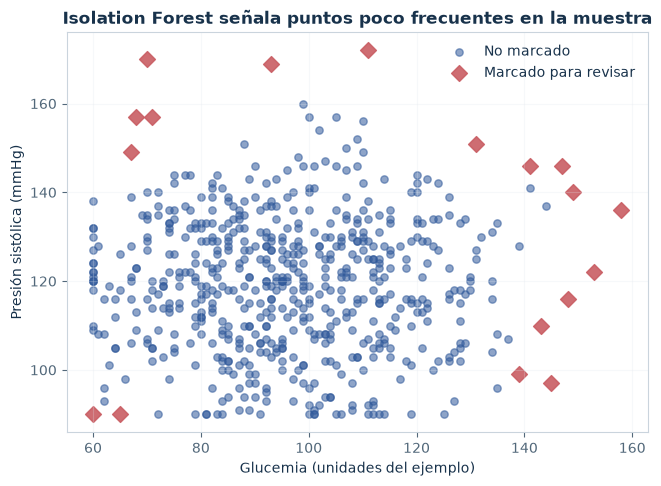

In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

Xa = df[["glucemia", "tension_sistolica"]]
Xa_esc = StandardScaler().fit_transform(Xa)
detector = IsolationForest(contamination=0.03, random_state=SEED)
marca = detector.fit_predict(Xa_esc)  # -1: marcado como inusual; 1: patrón habitual
fig, ax = plt.subplots(figsize=(7.5, 5.2))
habitual = marca == 1
ax.scatter(Xa.loc[habitual, "glucemia"], Xa.loc[habitual, "tension_sistolica"], s=28, alpha=0.55, color=PALETTE["azul"], label="No marcado")
ax.scatter(Xa.loc[~habitual, "glucemia"], Xa.loc[~habitual, "tension_sistolica"], s=65, alpha=0.9, color=PALETTE["rojo"], marker="D", label="Marcado para revisar")
ax.set_xlabel("Glucemia (unidades del ejemplo)")
ax.set_ylabel("Presión sistólica (mmHg)")
ax.set_title("Isolation Forest señala puntos poco frecuentes en la muestra")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

Una marca roja pide mirar el registro y su contexto. Puede tratarse de un error de carga, una lectura válida pero poco frecuente o una situación distinta. El algoritmo no explica cuál es la causa ni diagnostica una condición.

## 07 · Si el orden temporal importa

Cuando una aplicación recibe mediciones sucesivas —por ejemplo, lecturas de un sensor— el orden importa. La muestra compara lecturas previas con las siguientes en una señal **simulada**, usando datos anteriores para estimar un paso más adelante.

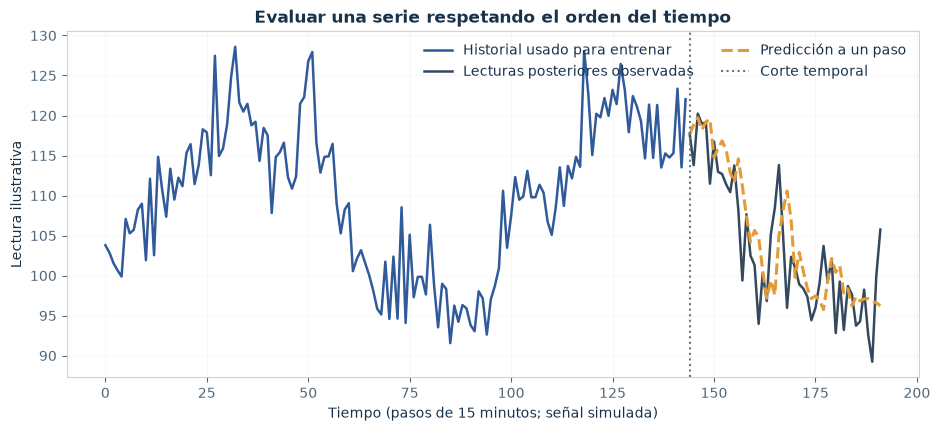

In [11]:
from sklearn.ensemble import RandomForestRegressor

rng = np.random.default_rng(17)
pasos = 192  # 48 horas con una lectura cada 15 minutos
indice = np.arange(pasos)
senal = (
    108 + 12 * np.sin(2 * np.pi * indice / 96 - 0.7)
    + 3.5 * np.sin(2 * np.pi * indice / 24)
    + rng.normal(0, 3.2, pasos)
)
for pico in [48, 116, 164]:
    senal[pico:pico + 5] += np.array([4, 9, 13, 8, 3])
rezagos = 8
Xserie, yserie, momentos = [], [], []
for t in range(rezagos, pasos):
    Xserie.append(senal[t-rezagos:t])
    yserie.append(senal[t])
    momentos.append(t)
Xserie = np.asarray(Xserie); yserie = np.asarray(yserie); momentos = np.asarray(momentos)
corte = 144 - rezagos
modelo_temporal = RandomForestRegressor(n_estimators=150, min_samples_leaf=4, random_state=SEED)
modelo_temporal.fit(Xserie[:corte], yserie[:corte])
pred_serie = modelo_temporal.predict(Xserie[corte:])
instantes_test = momentos[corte:]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(indice[:144], senal[:144], color=PALETTE["azul"], linewidth=1.8, label="Historial usado para entrenar")
ax.plot(indice[144:], senal[144:], color="#34495e", linewidth=1.8, label="Lecturas posteriores observadas")
ax.plot(instantes_test, pred_serie, color=PALETTE["naranja"], linewidth=2.2, linestyle="--", label="Predicción a un paso")
ax.axvline(144, color=PALETTE["gris"], linestyle=":", linewidth=1.5, label="Corte temporal")
ax.set_xlabel("Tiempo (pasos de 15 minutos; señal simulada)")
ax.set_ylabel("Lectura ilustrativa")
ax.set_title("Evaluar una serie respetando el orden del tiempo")
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.25)
plt.show()

La línea vertical marca dónde dejamos de aprender y empezamos a revisar predicciones. Es importante no mezclar al azar datos de antes y después: en una serie, eso podría dejar que el futuro se filtre al pasado.

En salud, una secuencia podría representar signos vitales o glucosa de un sensor. El gráfico de esta celda no viene de un paciente ni tiene unidades clínicas.

### Un caso particular: tiempo hasta un evento

Para una reconsulta puede interesar cuándo ocurre, no solo si ocurre. Si el periodo de observación termina antes de saberlo, conocemos hasta qué momento hubo seguimiento, pero no el momento final del evento. Ese caso incompleto se llama **censura**.

La curva Kaplan–Meier resume en el tiempo qué proporción sigue sin el evento observado. Es un concepto para reconocer, no hace falta aprender ahora el cálculo.

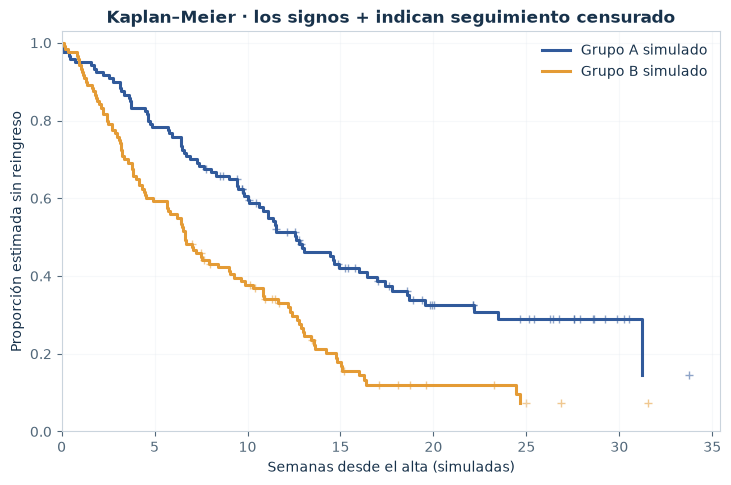

In [12]:
rng = np.random.default_rng(202)
n = 240
grupo = np.repeat(["Grupo A simulado", "Grupo B simulado"], n // 2)
tasa = np.where(grupo == "Grupo A simulado", 0.055, 0.095)
tiempo_evento = rng.exponential(1 / tasa)
tiempo_cierre = rng.uniform(7, 34, n)
evento_observado = tiempo_evento <= tiempo_cierre
tiempo_observado = np.minimum(tiempo_evento, tiempo_cierre)

def curva_km(tiempos, eventos):
    momentos = np.sort(np.unique(tiempos[eventos]))
    supervivencia = 1.0
    x = [0.0]; y = [1.0]
    for t in momentos:
        en_riesgo = np.sum(tiempos >= t)
        eventos_t = np.sum((tiempos == t) & eventos)
        supervivencia *= (1 - eventos_t / en_riesgo)
        x.append(float(t)); y.append(float(supervivencia))
    return np.array(x), np.array(y)

def valor_km(t, tiempos, eventos):
    x, y = curva_km(tiempos, eventos)
    return y[np.searchsorted(x, t, side="right") - 1]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for nombre, color in [("Grupo A simulado", PALETTE["azul"]), ("Grupo B simulado", PALETTE["naranja"])]:
    m = grupo == nombre
    t = tiempo_observado[m]; e = evento_observado[m]
    x, y = curva_km(t, e)
    ax.step(x, y, where="post", color=color, linewidth=2.2, label=nombre)
    censurados = ~e
    yc = [valor_km(tc, t, e) for tc in t[censurados]]
    ax.scatter(t[censurados], yc, marker="+", color=color, alpha=0.55, s=36, linewidth=1)
ax.set_xlim(left=0)
ax.set_ylim(0, 1.03)
ax.set_xlabel("Semanas desde el alta (simuladas)")
ax.set_ylabel("Proporción estimada sin reingreso")
ax.set_title("Kaplan–Meier · los signos + indican seguimiento censurado")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

Las curvas y los grupos de esta figura fueron generados para la clase. Los signos `+` representan seguimientos que terminaron sin observar el evento. Para estudiar casos reales harían falta una definición precisa del evento, fechas confiables y una evaluación independiente.

## 08 · Cuando la entrada es una imagen o una nota

Hay problemas donde la información principal no está en una tabla. En imágenes, la salida puede ser una categoría, una caja que ubica una región o una máscara que señala píxeles. La ilustración es esquemática; no se entrenó un modelo médico.

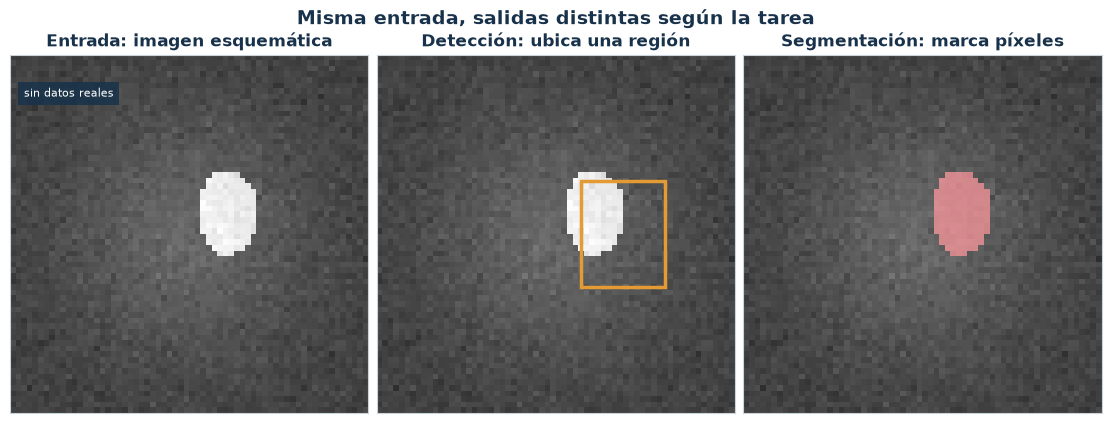

In [13]:
rng = np.random.default_rng(5)
yg, xg = np.mgrid[-1:1:64j, -1:1:64j]
mascara = ((xg - 0.22) ** 2 / 0.17 ** 2 + (yg + 0.12) ** 2 / 0.24 ** 2) < 1
imagen = 0.25 + 0.15 * np.exp(-(xg**2 + yg**2) / 0.5) + rng.normal(0, 0.025, xg.shape)
imagen = np.clip(imagen + 0.55 * mascara, 0, 1)
fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), constrained_layout=True)
axes[0].imshow(imagen, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Entrada: imagen esquemática")
axes[0].text(2, 7, "sin datos reales", color="white", fontsize=8, bbox={"facecolor": "#18324b", "alpha": 0.85, "edgecolor": "none"})
axes[1].imshow(imagen, cmap="gray", vmin=0, vmax=1)
axes[1].add_patch(plt.Rectangle((36, 22), 15, 19, fill=False, edgecolor=PALETTE["naranja"], linewidth=2.5))
axes[1].set_title("Detección: ubica una región")
axes[2].imshow(imagen, cmap="gray", vmin=0, vmax=1)
axes[2].imshow(np.ma.masked_where(~mascara, mascara), cmap=ListedColormap([PALETTE["rojo"]]), alpha=0.7)
axes[2].set_title("Segmentación: marca píxeles")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Misma entrada, salidas distintas según la tarea", fontsize=14, fontweight="bold")
plt.show()

El dibujo cambia la **forma de la respuesta**: una clase para toda la imagen, una caja alrededor de un objeto o píxeles coloreados. En un producto de salud habría que validar imágenes representativas y evitar mezclar a la misma persona entre entrenamiento y evaluación.

En notas clínicas, NLP puede encontrar menciones o sugerir categorías. Pero el contexto importa: «niega fiebre» y «refiere fiebre» contienen la misma palabra, con sentidos distintos.

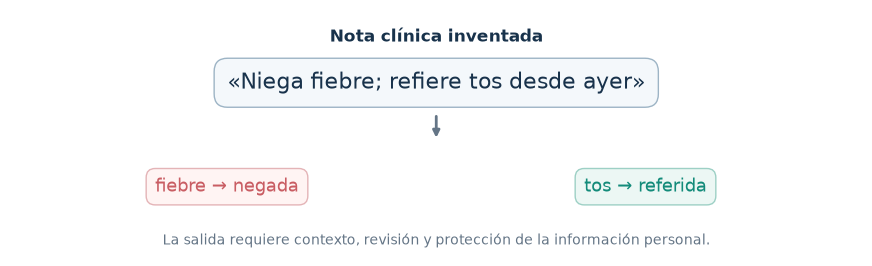

In [14]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 11); ax.set_ylim(0, 3.2); ax.axis("off")
ax.text(5.5, 2.85, "Nota clínica inventada", ha="center", va="center", fontsize=12, fontweight="bold", color="#18324b")
ax.text(5.5, 2.25, "«Niega fiebre; refiere tos desde ayer»", ha="center", va="center", fontsize=16,
        bbox={"boxstyle": "round,pad=0.6", "facecolor": "#f4f8fb", "edgecolor": "#9db4c5"})
ax.annotate("", xy=(5.5, 1.5), xytext=(5.5, 1.85), arrowprops={"arrowstyle": "-|>", "color": PALETTE["gris"], "lw": 2})
ax.text(2.8, 0.9, "fiebre → negada", ha="center", va="center", fontsize=13, color=PALETTE["rojo"],
        bbox={"boxstyle": "round,pad=0.5", "facecolor": "#fff4f3", "edgecolor": "#e4b4b7"})
ax.text(8.2, 0.9, "tos → referida", ha="center", va="center", fontsize=13, color=PALETTE["verde"],
        bbox={"boxstyle": "round,pad=0.5", "facecolor": "#ecf7f4", "edgecolor": "#9dd0c5"})
ax.text(5.5, 0.15, "La salida requiere contexto, revisión y protección de la información personal.", ha="center", fontsize=10, color=PALETTE["gris"])
plt.show()

La figura marca el sentido en una frase inventada. Una extracción automática debe conservar la negación y la nota de origen para que pueda revisarse; no debe transformarse por sí sola en diagnóstico o indicación.

## 09 · Lo que conviene llevar a un proyecto

| Si la pregunta pide… | Empezá por… | Y verificá… |
|---|---|---|
| Una categoría | Clasificación | Qué significa la etiqueta y qué errores importan |
| Un número | Regresión | Unidad del error y casos extremos |
| Grupos sin categorías anteriores | Clustering | Si el patrón es estable y útil |
| Casos raros | Anomalías | Qué revisión humana sigue a la marca |
| Próxima medición o evento | Serie temporal / supervivencia | Orden, horizonte y datos incompletos |
| Salida desde imagen o texto | Visión / NLP | Calidad de entrada, contexto y población representada |

Como quienes construyen el sistema, mantengan a la vista el momento de predicción, los datos permitidos, la versión del modelo, los resultados que muestra la interfaz y el mecanismo de revisión. Una predicción es una estimación para apoyar una tarea, no una acción automática.

### Actividad de cierre: diseñar el primer borrador del sistema

En grupos, elijan una de estas preguntas y anoten cinco decisiones. No hace falta escribir código:

- ordenar estudios para revisión;
- estimar la demanda diaria de camas;
- explorar perfiles en controles preventivos;
- encontrar mediciones posiblemente cargadas con error.

Completen: **fila de la tabla → columnas disponibles al decidir → respuesta esperada → familia inicial → cómo separarían los casos para probarla**. Al final agreguen dónde se mostraría la salida y quién revisaría un caso dudoso.

### Referencias y material para seguir

- [Mapa visual de selección de modelos — scikit-learn (SVG)](https://scikit-learn.org/stable/_downloads/b82bf6cd7438a351f19fac60fbc0d927/ml_map.svg) y [guía de modelos y evaluación](https://scikit-learn.org/stable/user_guide.html).
- [Árboles de decisión: ejemplos — scikit-learn](https://scikit-learn.org/stable/modules/tree.html).
- [TRIPOD+AI: guía para describir y evaluar modelos de predicción clínica](https://www.bmj.com/content/385/bmj-2023-078378).
- [OMS: ética y gobernanza de IA para la salud](https://www.who.int/publications/i/item/9789240029200).
- Video opcional: [Regresión logística, explicado por StatQuest](https://www.youtube.com/watch?v=yIYKR4sgzI8).
- Video opcional: [Bosques aleatorios: construcción y evaluación, StatQuest](https://www.youtube.com/watch?v=J4Wdy0Wc_xQ).

## Para cerrar

> **Primero describí la pregunta, los datos y el momento de uso.** Después elegí unas pocas familias candidatas y comparalas en casos que no se usaron para aprender.
>
> El equipo de desarrollo no necesita memorizar cada algoritmo para construir bien la solución. Sí necesita saber qué recibe, qué estima, qué errores puede cometer y cómo integrar revisión y monitoreo.